In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rc
import pandas as pd

ttcdata = pd.read_csv(r'C:\Users\james\Documents\DSI\visualization\02_activities\assignments\TTC LRT Delays.csv')

print(ttcdata.head())

   _id        Date Line  Time     Day                 Station   Code  \
0    1  2025-12-07   FW  7:29  Sunday  FINCH WEST FWLRT STATI  TXDOE   
1    2  2025-12-07   FW  9:17  Sunday      MILVAN RUMIKE STOP   EXTM   
2    3  2025-12-07   FW  9:25  Sunday      MILVAN RUMIKE STOP   EXBK   
3    4  2025-12-07   FW  9:34  Sunday     HUMBER COLLEGE STOP   EXBO   
4    5  2025-12-07   FW  9:55  Sunday     HUMBER COLLEGE STOP   MXTO   

   Min Delay  Min Gap Bound  Vehicle  
0          0        0     W     6509  
1          7       17     W     6501  
2          5       15     E     6512  
3          4       14     E     6502  
4          5       15   NaN     6508  


In [18]:
ttcdf = ttcdata.pivot_table(index='Date', 
                          columns='Code', 
                          values='Min Delay', 
                          aggfunc='sum', 
                          fill_value=0)

# check the raw data
print(ttcdf)

Code        EXAC  EXATC  EXBK  EXBO  EXCE  EXDO  EXECD  EXGA  EXHV  EXNEA  \
Date                                                                        
2025-12-07     0      0    14     4     0     0      0     0     0      0   
2025-12-08    12      0     9     0     0    10      0     0     0      0   
2025-12-09     0      0     0     0     0     6      0     0     0      0   
2025-12-10     0      0     0     0     0     0      0     0     0      0   
2025-12-11     0      0     0     0    12     0      0     0     0     12   
2025-12-12     7     17     7    20    10     3      0     0     0      0   
2025-12-13     0      0    32     0     0     4     37    30     0      0   
2025-12-14     6      0   119     0     0     3      0     0     0      0   
2025-12-15     6      0     0     4     0     0      0     0     0      0   
2025-12-16    20      0    23     0    25     0      0    26     0      0   
2025-12-17    65      8     5     0     0     0      0     0     0     12   

In [19]:
# find codes associated with significant delays (over 60 minutes)
ttcdf.max()

Code
EXAC      65
EXATC     17
EXBK     119
EXBO      20
EXCE      25
EXDO      10
EXECD     37
EXGA      30
EXHV       0
EXNEA     16
EXO      122
EXSA      14
EXTM      11
EXTR       5
EXWA       6
EXWS      10
EXYRD     17
MXAFR    114
MXD        8
MXGD       0
MXIE      14
MXIR     154
MXIRS      5
MXIS       0
MXNOA     10
MXO       15
MXPAA      4
MXPLC    186
MXST       0
MXTO      24
MXUS      40
MXWEA     35
PXDCS    202
PXEAS      0
PXSCA      0
PXSIS    200
PXSTP      3
PXSW     443
PXTDN      6
PXTIS     15
PXTS       5
PXWZ      14
SXDP       0
SXO        0
SXUEG      7
TXCC       4
TXCL       5
TXDOE     10
TXNIP     15
TXNOA     22
TXO       14
TXOS      17
TXOVS      6
TXS       15
TXST       0
TXSUP      3
dtype: int64

In [20]:
# create a list of major delay codes
sorted_df = ttcdf[ttcdf.max().sort_values(ascending=False).index]
major_delays = [n for n in sorted_df.columns if sorted_df[n].max() > 60]
major_delays

['PXSW', 'PXDCS', 'PXSIS', 'MXPLC', 'MXIR', 'EXO', 'EXBK', 'MXAFR', 'EXAC']

In [21]:
# map major delay codes to descriptive names
major_delay_codes = {
    'EXAC': 'HVAC Failure',
    'EXBK': 'Brake Failure',
    'EXO': 'Other Equipment Issue',
    'MXAFR': 'Auto Foul Rail',
    'MXIR': 'Injured/ill Customer',
    'MXPLC': 'Fire/Smoke',
    'PXDCS': 'Mechanical Issue',
    'PXSIS': 'Data Communications System Failure',
    'PXSW': 'Track Switch Failure',
    'Other': 'Other Causes'
}

# condense other delay codes into 'Other'
major_cols = [col for col in sorted_df.columns if col in major_delays]
other_cols = [col for col in sorted_df.columns if col not in major_delays]

trimmed_ttcdf = sorted_df[major_cols].copy()
if other_cols:
    trimmed_ttcdf['Other'] = sorted_df[other_cols].sum(axis=1)
    
# rename columns using the mapping
final_df = trimmed_ttcdf.rename(columns=major_delay_codes)

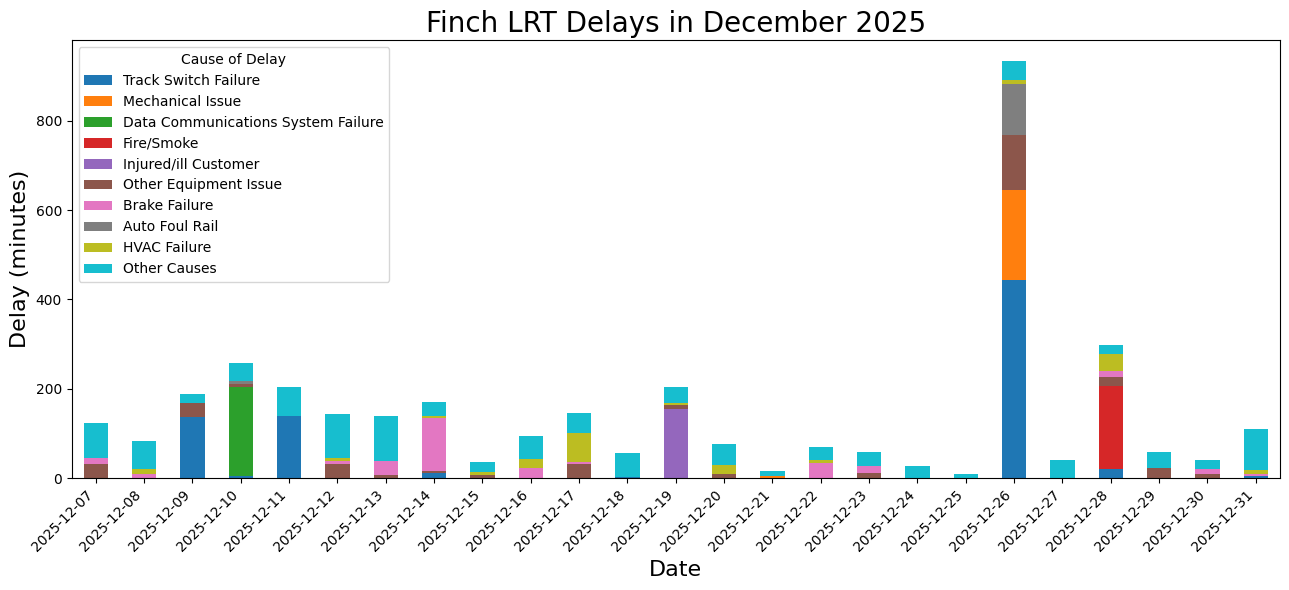

<Figure size 640x480 with 0 Axes>

In [22]:
# plot the stacked bar chart
ax = final_df.plot(kind='bar', stacked=True, figsize=(13, 6), colormap='tab10')

# customize the plot
plt.title('Finch LRT Delays in December 2025', size =20)
plt.xlabel('Date', size=16)
plt.ylabel('Delay (minutes)', size=16)
plt.legend(title='Cause of Delay')

plt.xticks(rotation=45, ha='right', size=10)
plt.tight_layout()

plt.show()
plt.savefig('LRT_delays_by_direction.png')